In [2]:
import matplotlib.pyplot as plt

# LANDSAT VS SENTINEL

# CART VS RF

# UVW VS UVWO VS UVWOB

## Eval - Confusion Matrix & Accuracy

# Accuracy

Two subplots:
1. A plot from LANDSAT with two bar charts -
<ol>
    <li>Bar chart with CART with accuracies for three classes</li>
    <li>Bar chart with RF with accuracies for three classes</li>
</ol>
2. A plot from Sentinel with two bar charts -
<ol>
    <li>Bar chart with CART with accuracies for three classes</li>
    <li>Bar chart with RF with accuracies for three classes</li>
</ol>

In [ ]:
accuracy_results = {
    "Landsat 8": {
        "CART": {"UVW": 0.9180, "UVWO": 0.7632, "UVWOB": 0.7994},
        "RF100": {"UVW": 0.9346, "UVWO": 0.8442, "UVWOB": 0.8241} 
    },
    "Sentinel 2A": {
        "CART": {"UVW": 0.8714, "UVWO": 0.7852, "UVWOB": 0.7760},
        "RF100": {"UVW": 0.9314, "UVWO": 0.8635, "UVWOB": 0.8359}
    }
}

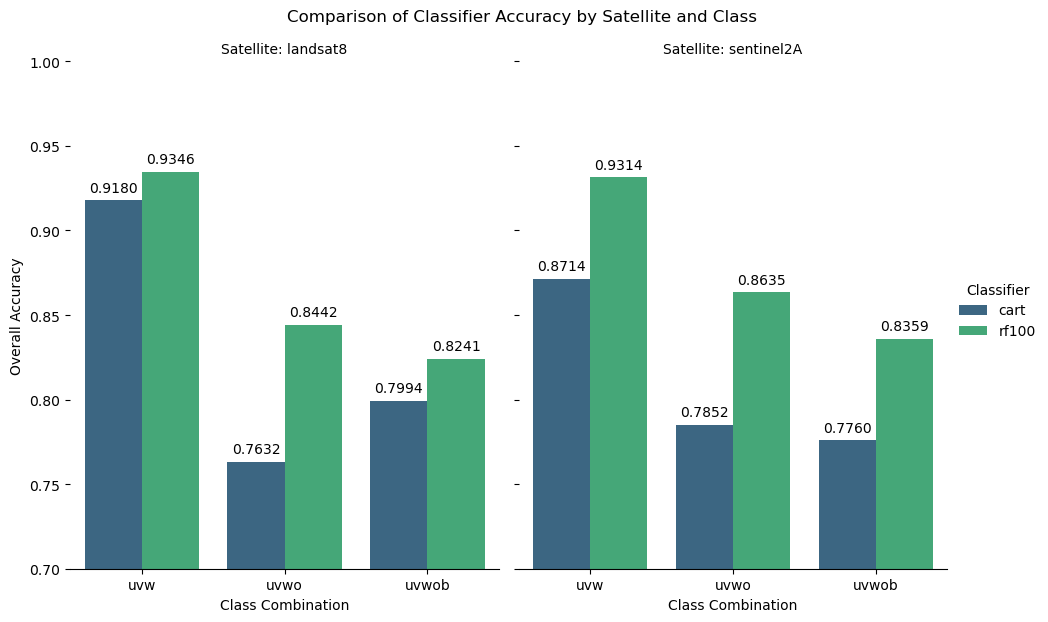

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

records = []
for satellite, classifiers in accuracy_results.items():
    for classifier, classes in classifiers.items():
        for class_name, accuracy in classes.items():
            records.append({
                "Satellite": satellite,
                "Classifier": classifier,
                "Class": class_name,
                "Accuracy": accuracy
            })

df = pd.DataFrame(records)
g = sns.catplot(
    data=df,
    kind="bar",
    x="Class",
    y="Accuracy",
    hue="Classifier",
    col="Satellite",      # Create separate columns for each satellite
    palette="viridis",    # Color scheme for the bars
    height=6,             # Height of each plot
    aspect=0.8            # Aspect ratio of each plot
)

for ax in g.axes.flat:
    # Iterate through the bars (patches) in each subplot
    for p in ax.patches:
        ax.annotate(
            format(p.get_height(), '.4f'),  # The text to display, formatted to 4 decimal places
            (p.get_x() + p.get_width() / 2., p.get_height()),  # The (x, y) coordinate for the text
            ha='center',          # Horizontal alignment
            va='center',          # Vertical alignment
            xytext=(0, 9),        # The vertical offset (in points) from the coordinate
            textcoords='offset points'
        )
        
# 5. Add titles and labels for clarity
g.figure.suptitle('Comparison of Classifier Accuracy by Satellite and Class', y=1.03)
g.set_axis_labels("Class Combination", "Overall Accuracy")
g.set_titles("Satellite: {col_name}")
g.despine(left=True)

# Adjust y-axis to better highlight the differences between high accuracy values
plt.ylim(0.7, 1.0)

# 6. Save the figure to a file
# Use bbox_inches='tight' to ensure all labels fit in the saved image
plt.savefig('accuracy_comparison.png', bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
I = plt.imread()

In [26]:
import rasterio
import numpy as np
from matplotlib import pyplot as plt

# Define the path to your TIFF file
file_path = 'images/Sentinel2A/SENTINEL-RF100-UVW.tif'

try:
    # Open the TIFF file
    with rasterio.open(file_path) as src:
        # Read the first three bands into a 3D numpy array
        # The data is read as (bands, height, width)
        rgb_bands = src.read((1, 2, 3))

        # Check for empty or invalid data
        if rgb_bands.size == 0:
            print(f"Error: No data found in bands 1, 2, 3 of {file_path}")
        else:
            # Matplotlib expects image data in the format (height, width, bands)
            # We use np.dstack to rearrange the bands
            rgb_image = np.dstack((rgb_bands[0], rgb_bands[1], rgb_bands[2]))

            # Display the image
            plt.figure(figsize=(8, 8))
            plt.imshow(rgb_image)
            plt.title('TIFF Image Display')
            plt.axis('off')  # Hide the axes
            plt.show()

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading file: {e}")

IndexError: band index 2 out of range (not in (1,))

# Confusion Matrix

In [8]:
landsat8_cart_uvw = [
    [67, 4, 3],
    [0, 198, 7],
    [9, 6, 60]
]

landsat8_cart_uvwo = [
    [65, 2, 9, 0],
    [2, 143, 3, 32],
    [7, 3, 51, 3],
    [0, 21, 3, 15]
]

landsat8_cart_uvwob = [
    [22, 0, 0, 0, 4],
    [0, 152, 9, 19, 1],
    [0, 5, 51, 1, 3],
    [0, 20, 5, 27, 0],
    [0, 3, 3, 0, 39]
]

landsat8_rf100_uvw = [
    [47, 1, 4],
    [0, 187, 2],
    [3, 10, 52]
]
landsat8_rf100_uvwo = [
    [57, 3, 3, 0],
    [0, 187, 0, 5],
    [5, 4, 49, 4],
    [0, 30, 3, 16]
]
landsat8_rf100_uvwob = [
    [21, 0, 0, 0, 5],
    [0, 163, 3, 13, 2],
    [0, 5, 52, 1, 2],
    [0, 20, 8, 24, 0],
    [0, 3, 2, 0, 40]
]

sentinel2a_cart_uvw = [
    [68, 4, 9],
    [7, 188, 9],
    [6, 10, 49]
]
sentinel2a_cart_uvwo = [
    [63, 3, 10, 0],
    [2, 147, 6, 15],
    [5, 5, 48, 4],
    [0, 19, 4, 9]
]
sentinel2a_cart_uvwob = [
    [44, 0, 0, 0, 2],
    [0, 146, 8, 18, 2],
    [0, 4, 54, 3, 6],
    [0, 21, 6, 25, 1],
    [10, 2, 3, 0, 29]
]

sentinel2a_rf100_uvwob = [
    [49, 0, 0, 0, 0],
    [0, 182, 7, 9, 1],
    [0, 9, 45, 4, 4],
    [0, 17, 1, 15, 1],
    [2, 2, 2, 0, 18]
]
sentinel2a_rf100_uvwo = [
    [96, 2, 5, 0],
    [0, 161, 4, 4],
    [3, 4, 56, 2],
    [0, 27, 1, 16]
]
sentinel2a_rf100_uvw = [
    [83, 1, 3],
    [2, 187, 2],
    [3, 13, 56]
]

In [18]:
landsat8_cart_uvw = np.array(landsat8_cart_uvw)
landsat8_cart_uvwo = np.array(landsat8_cart_uvwo)
landsat8_cart_uvwob = np.array(landsat8_cart_uvwob)

landsat8_rf100_uvw = np.array(landsat8_rf100_uvw)
landsat8_rf100_uvwo = np.array(landsat8_rf100_uvwo)
landsat8_rf100_uvwob = np.array(landsat8_rf100_uvwob)

sentinel2a_cart_uvw = np.array(sentinel2a_cart_uvw)
sentinel2a_cart_uvwo = np.array(sentinel2a_cart_uvwo)
sentinel2a_cart_uvwob = np.array(sentinel2a_cart_uvwob)

sentinel2a_rf100_uvw = np.array(sentinel2a_rf100_uvw)
sentinel2a_rf100_uvwo = np.array(sentinel2a_rf100_uvwo)
sentinel2a_rf100_uvwob = np.array(sentinel2a_rf100_uvwob)

In [23]:
all_matrices = {
    "Landsat8 CART UVW": landsat8_cart_uvw,
    "Landsat8 CART UVWO": landsat8_cart_uvwo,
    "Landsat8 CART uvwob": landsat8_cart_uvwob,
    "Landsat8  UVW": landsat8_rf100_uvw,
    "Landsat8 Random Forest UVWO": landsat8_rf100_uvwo,
    "Landsat8 Random Forest UVWOB": landsat8_rf100_uvwob,
    "Sentinel2a CART UVW": sentinel2a_cart_uvw,
    "Sentinel2a CART UVWO": sentinel2a_cart_uvwo,
    "Sentinel2a CART UVWOB": sentinel2a_cart_uvwob,
    "Sentinel2a Random Forest UVW": sentinel2a_rf100_uvw,
    "Sentinel2a Random Forest UVWO": sentinel2a_rf100_uvwo,
    "Sentinel2a Random Forest UVWOB": sentinel2a_rf100_uvwob
}

In [24]:
import numpy as np
from sklearn import metrics

In [ ]:
for name, matrix in all_matrices.items():
    cm_display = metrics.ConfusionMatrixDisplay(
        confusion_matrix = matrix, display_labels = range(len(matrix))
        )
    cm_display.plot()
    plt.title(name)
    plt.savefig(name+'.png')

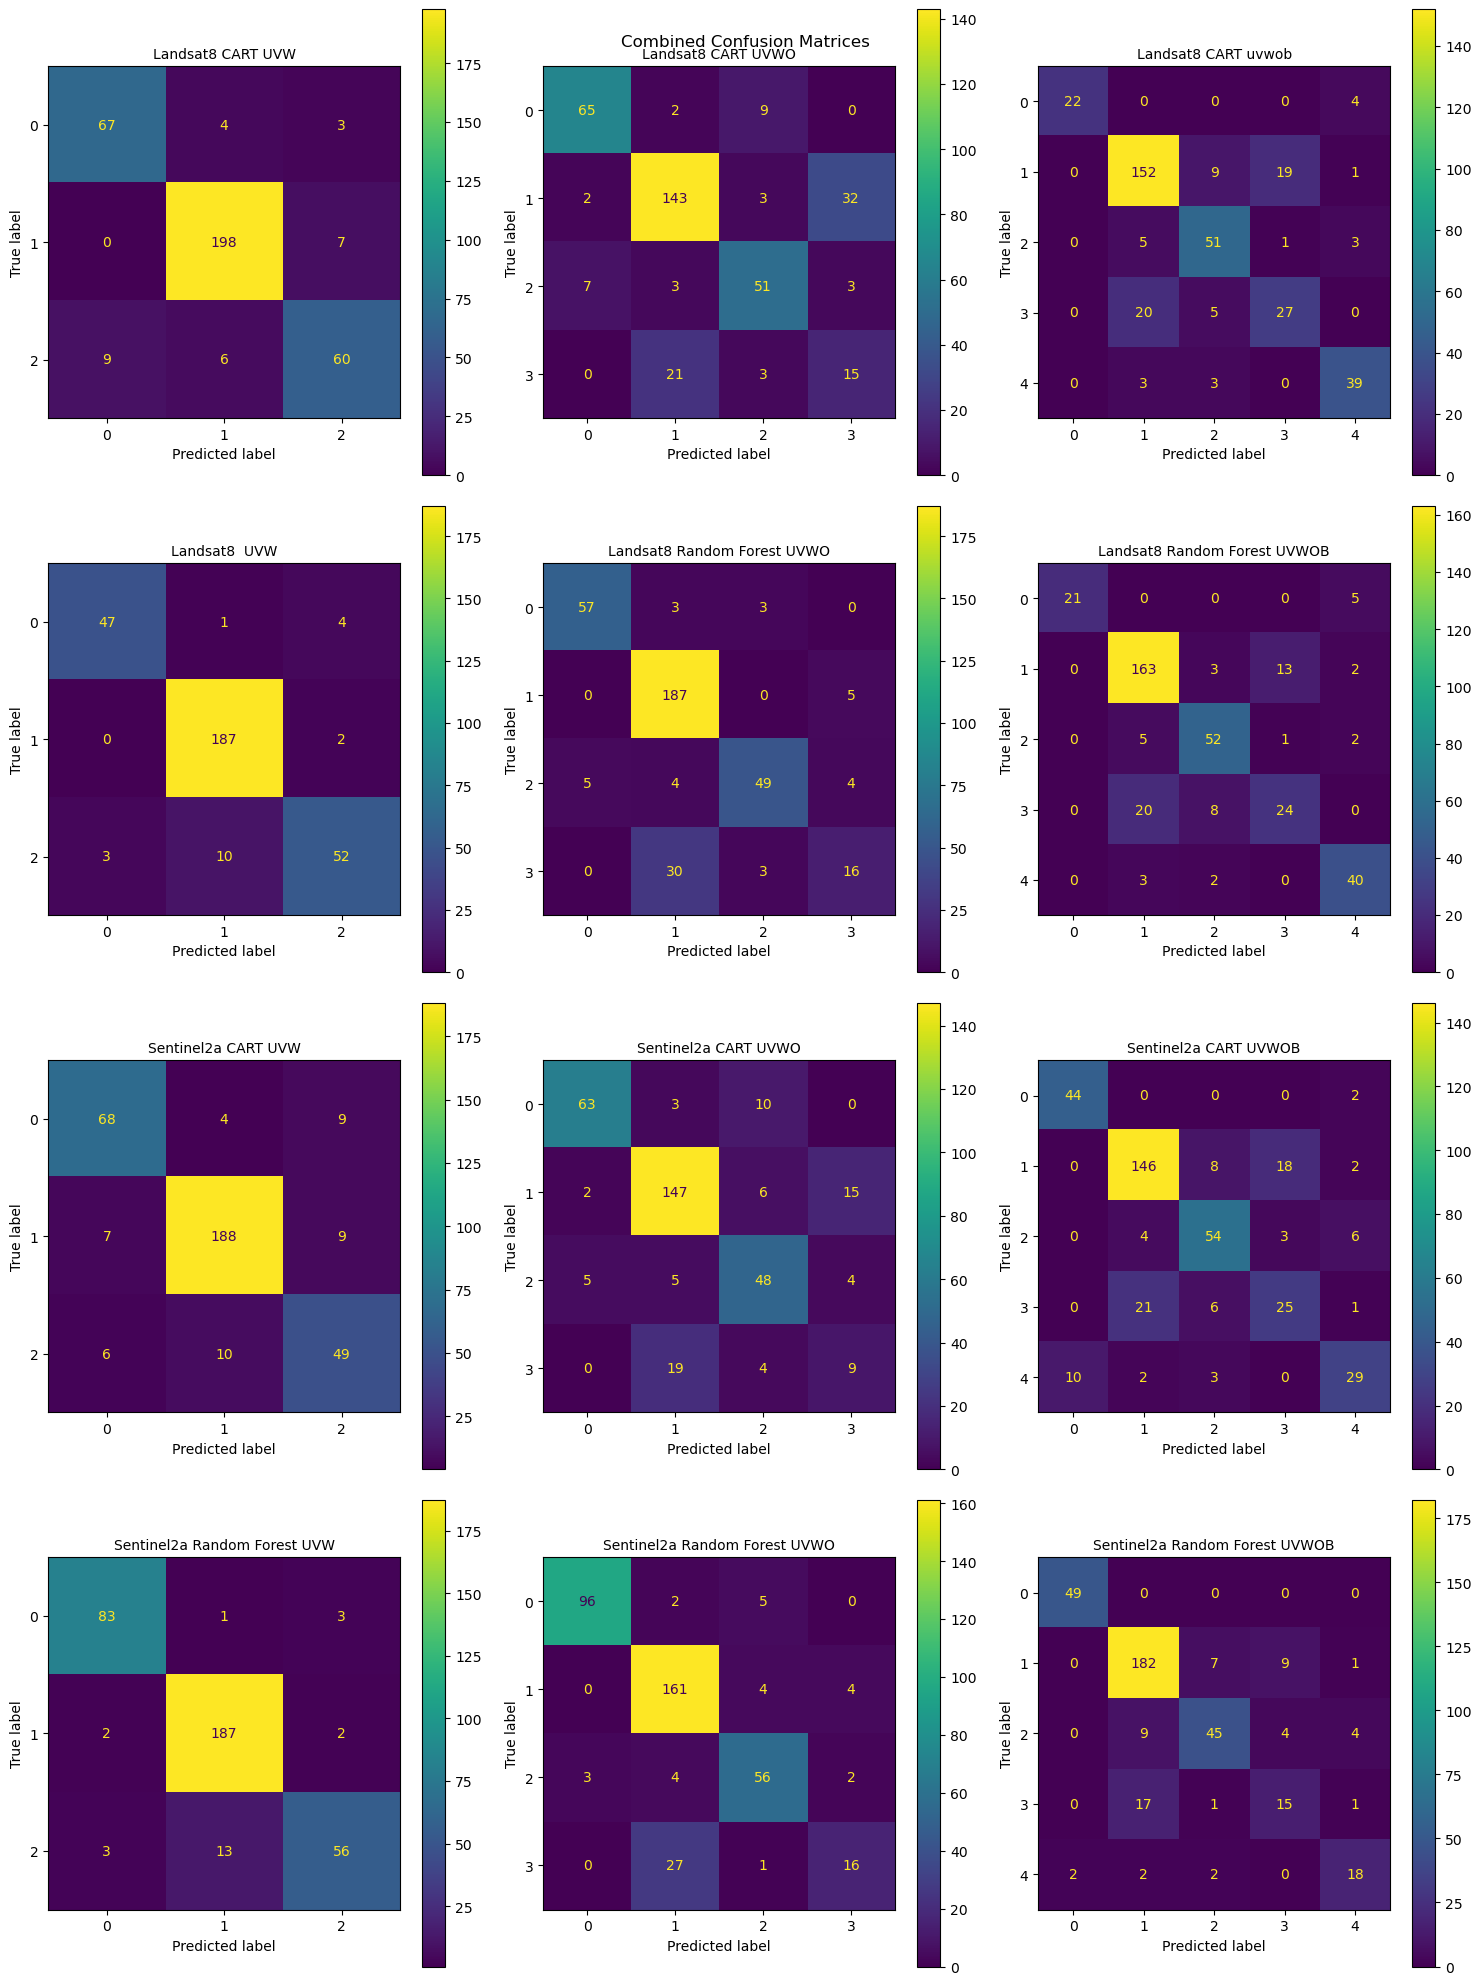

In [26]:
# Create figure with subplots (4 rows x 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot each confusion matrix
for idx, (name, matrix) in enumerate(all_matrices.items()):
    cm_display = metrics.ConfusionMatrixDisplay(
        confusion_matrix=matrix, 
        display_labels=range(len(matrix))
    )
    cm_display.plot(ax=axes[idx])
    axes[idx].set_title(name, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the combined plot
plt.suptitle("Combined Confusion Matrices")
plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Area Comparison

In [1]:
total_area = 1309.5899318943566

In [3]:
import json

In [4]:
with open('/home/pranav-rao/Documents/Remote GIS/LULC-Classification-Mumbai/LULC/results/Areas/uvwob_sentinel.geojson') as f:
    five_data = json.load(f)

In [5]:
with open('/home/pranav-rao/Documents/Remote GIS/LULC-Classification-Mumbai/LULC/results/Areas/uvwo_sentinel.geojson') as f:
    four_data = json.load(f)

In [6]:
with open('/home/pranav-rao/Documents/Remote GIS/LULC-Classification-Mumbai/LULC/results/Areas/uvw_sentinel.geojson') as f:
    three_data = json.load(f)

In [7]:
clean_data = dict()

In [8]:
five_dict = dict()
for feature in five_data['features']:
    properties = feature['properties']
    area = properties['area_sq_km']
    class_name = properties['class_name']
    five_dict[class_name] = {'current_area': area, 'percentage': (area/total_area)*100}
clean_data[5] = five_dict

In [9]:
four_dict = dict()
for feature in four_data['features']:
    properties = feature['properties']
    area = properties['area_sq_km']
    class_name = properties['class_name']
    four_dict[class_name] = {'current_area': area, 'percentage': (area/total_area)*100}
clean_data[4] = four_dict    

In [10]:
three_dict = dict()
for feature in three_data['features']:
    properties = feature['properties']
    area = properties['area_sq_km']
    class_name = properties['class_name']
    three_dict[class_name] = {'current_area': area, 'percentage': (area/total_area)*100}
clean_data[3] = three_dict

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [21]:
normal_data = dict()
for i in clean_data:
    normal_data[i] = dict()
    for k in clean_data[i]:
        normal_data[i][k] = clean_data[i][k]['percentage']

In [29]:
normal_data

{5: {'Ocean': 8.09030647489242,
  'UrbanAreas': 44.593210795807956,
  'Vegetation': 17.30280853120563,
  'OtherLand': 8.221497293427012,
  'WaterBodies': 21.792176904670864},
 4: {'Ocean': 29.969973330220352,
  'UrbanAreas': 44.830623128516216,
  'Vegetation': 17.048994729836302,
  'OtherLand': 8.150408811425484},
 3: {'Ocean': 29.873906854964638,
  'UrbanAreas': 54.401427353379795,
  'Vegetation': 15.724665791636191}}

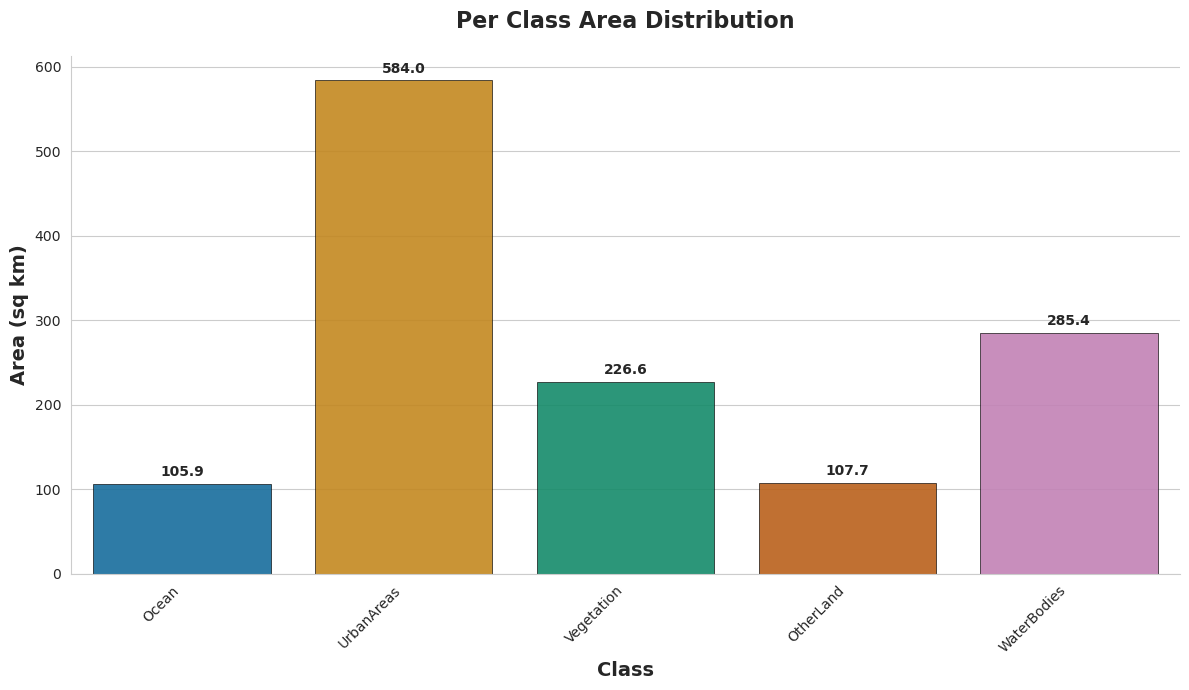

In [18]:
# Set seaborn style and color palette
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert data to DataFrame for easier handling
df = pd.DataFrame(list(normal_data[5].items()), columns=['Class', 'Area'])

# Create figure with better size
plt.figure(figsize=(12, 7))

# Create seaborn bar plot
ax = sns.barplot(data=df, x='Class', y='Area', 
                 hue='Class',
                 palette='colorblind', 
                 alpha=0.9,
                 edgecolor='black',
                 linewidth=0.5)

# Customize the plot
plt.xlabel('Class', fontsize=14, fontweight='bold')
plt.ylabel('Area (sq km)', fontsize=14, fontweight='bold')
plt.title('Per Class Area Distribution', fontsize=16, fontweight='bold', pad=20)

# Add value labels on top of bars
for i, (class_name, area) in enumerate(normal_data[5].items()):
    ax.text(i, area + max(normal_data[5].values()) * 0.01,
            f'{area:.1f}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Improve layout and remove top/right spines
sns.despine()
plt.tight_layout()

# Optional: Save the plot
plt.savefig('five_class_distribution.png', dpi=300, bbox_inches='tight')

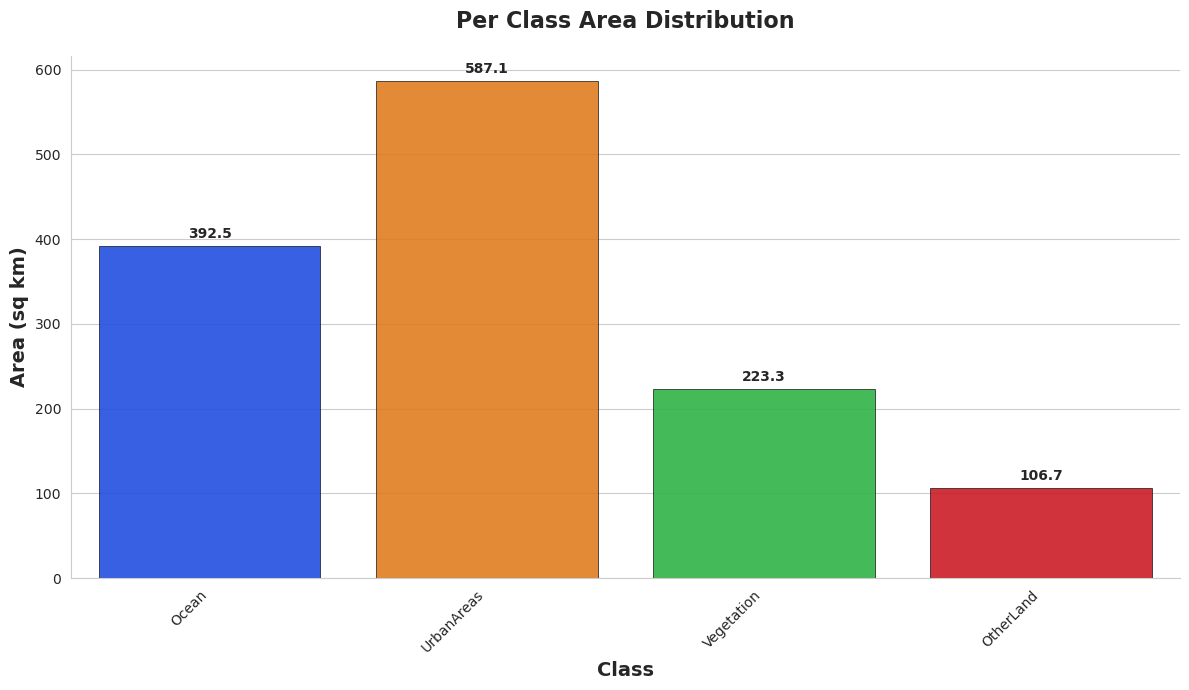

In [19]:
# Set seaborn style and color palette
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert data to DataFrame for easier handling
df = pd.DataFrame(list(normal_data[4].items()), columns=['Class', 'Area'])

# Create figure with better size
plt.figure(figsize=(12, 7))

# Create seaborn bar plot
ax = sns.barplot(data=df, x='Class', y='Area', 
                 hue='Class',
                 palette='bright', 
                 alpha=0.9,
                 edgecolor='black',
                 linewidth=0.5)

# Customize the plot
plt.xlabel('Class', fontsize=14, fontweight='bold')
plt.ylabel('Area (sq km)', fontsize=14, fontweight='bold')
plt.title('Per Class Area Distribution', fontsize=16, fontweight='bold', pad=20)

# Add value labels on top of bars
for i, (class_name, area) in enumerate(normal_data[4].items()):
    ax.text(i, area + max(normal_data[4].values()) * 0.01,
            f'{area:.1f}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Improve layout and remove top/right spines
sns.despine()
plt.tight_layout()

# Optional: Save the plot
plt.savefig('four_class_distribution.png', dpi=300, bbox_inches='tight')

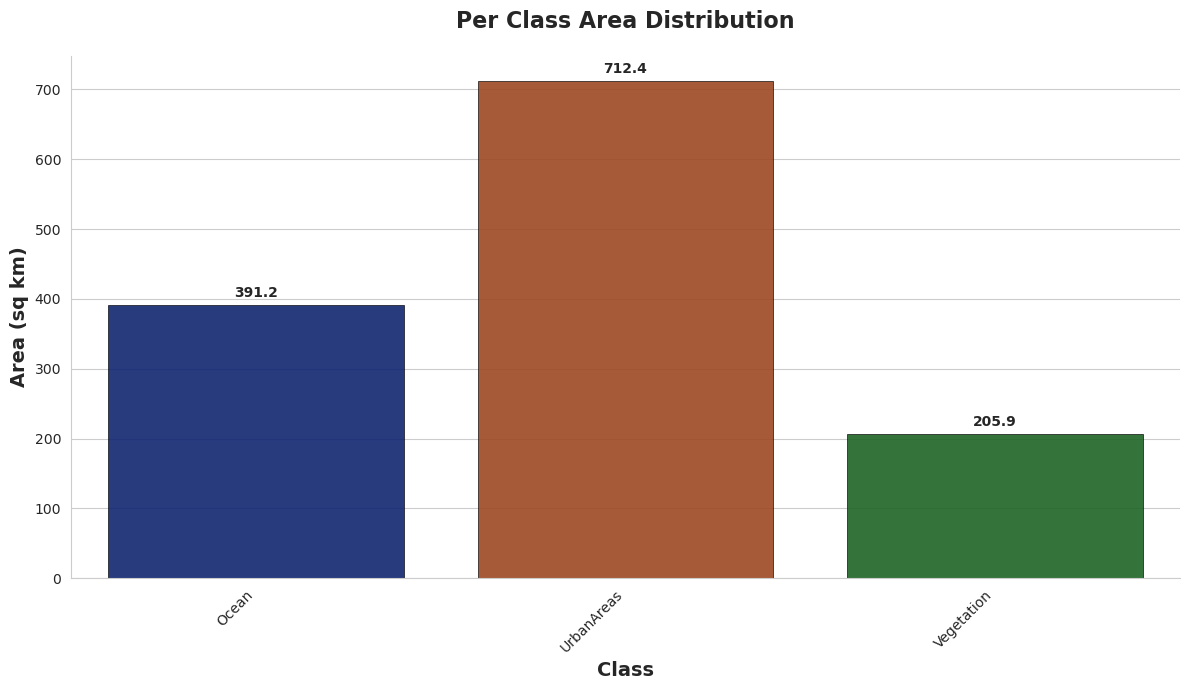

In [20]:
# Set seaborn style and color palette
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert data to DataFrame for easier handling
df = pd.DataFrame(list(normal_data[3].items()), columns=['Class', 'Area'])

# Create figure with better size
plt.figure(figsize=(12, 7))

# Create seaborn bar plot
ax = sns.barplot(data=df, x='Class', y='Area', 
                 hue='Class',
                 palette='dark', 
                 alpha=0.9,
                 edgecolor='black',
                 linewidth=0.5)

# Customize the plot
plt.xlabel('Class', fontsize=14, fontweight='bold')
plt.ylabel('Area (sq km)', fontsize=14, fontweight='bold')
plt.title('Per Class Area Distribution', fontsize=16, fontweight='bold', pad=20)

# Add value labels on top of bars
for i, (class_name, area) in enumerate(normal_data[3].items()):
    ax.text(i, area + max(normal_data[3].values()) * 0.01,
            f'{area:.1f}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Improve layout and remove top/right spines
sns.despine()
plt.tight_layout()

# Optional: Save the plot
plt.savefig('three_class_distribution.png', dpi=300, bbox_inches='tight')

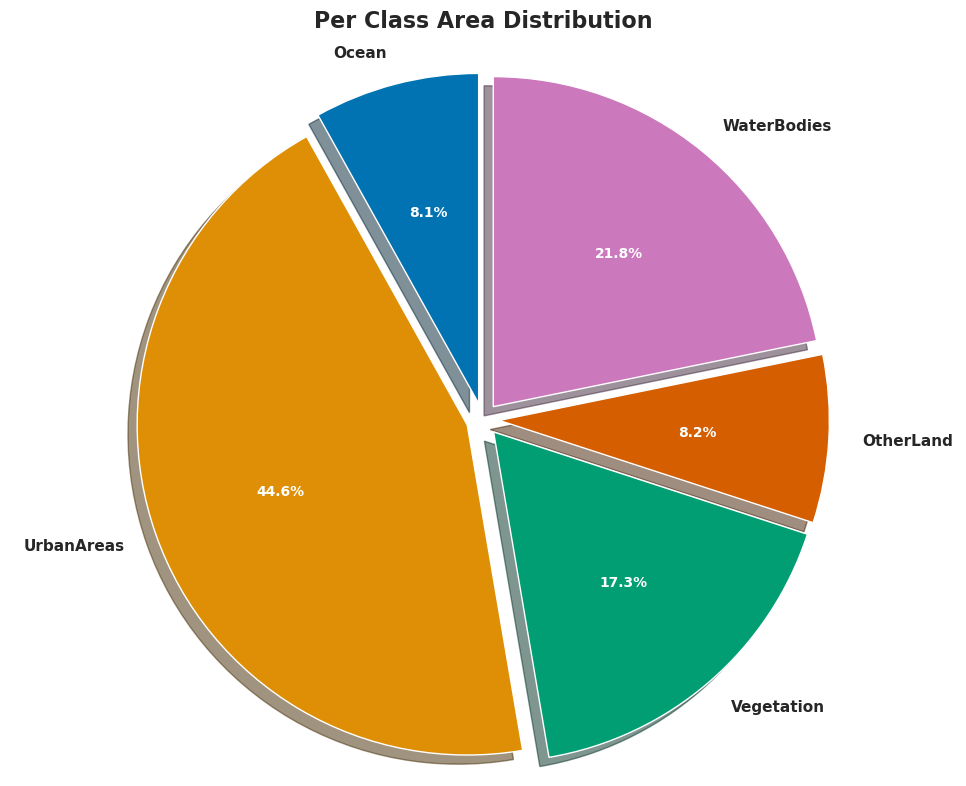

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn style for consistent aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

# Extract data
classes = list(normal_data[5].keys())
areas = list(normal_data[5].values())

# Create figure with better size
plt.figure(figsize=(10, 8))

# Use seaborn color palette
colors = sns.color_palette("colorblind", len(classes))
# Alternative palettes: "viridis", "Set2", "plasma", "deep", "pastel"

# Create pie chart with seaborn colors
wedges, texts, autotexts = plt.pie(areas, 
                                  labels=classes,
                                  colors=colors,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  explode=[0.05] * len(classes),  # Slight separation
                                  shadow=True,
                                  textprops={'fontweight': 'bold'})

# Customize the text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Improve label text
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')

# Add title
plt.title('Per Class Area Distribution', 
          fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Add a legend with area values
# legend_labels = [f'{cls}: {area:.1f} %' for cls, area in zip(classes, areas)]
# plt.legend(wedges, legend_labels,
#           title="Classes",
#           loc="center left",
#           bbox_to_anchor=(1, 0, 0.5, 1),
#           fontsize=10)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
# plt.show()

# Optional: Save the plot
plt.savefig('five_class_area_pie_chart.png', dpi=300, bbox_inches='tight')

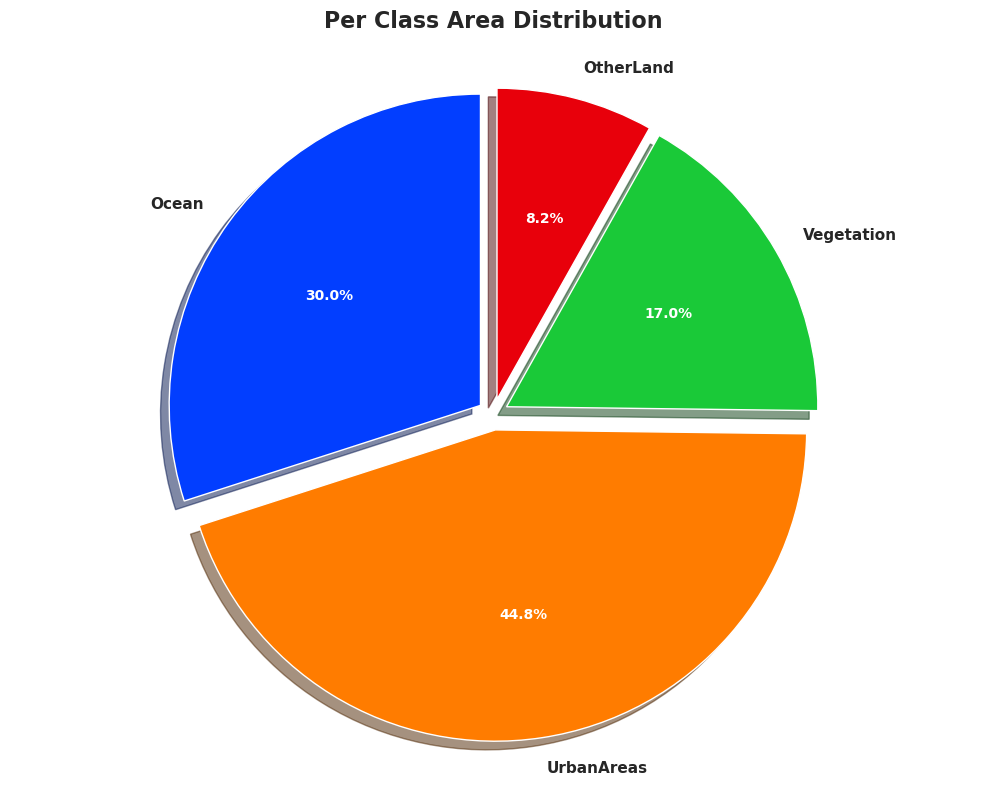

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn style for consistent aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

# Extract data
classes = list(normal_data[4].keys())
areas = list(normal_data[4].values())

# Create figure with better size
plt.figure(figsize=(10, 8))

# Use seaborn color palette
colors = sns.color_palette("bright", len(classes))
# Alternative palettes: "viridis", "Set2", "plasma", "deep", "pastel"

# Create pie chart with seaborn colors
wedges, texts, autotexts = plt.pie(areas, 
                                  labels=classes,
                                  colors=colors,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  explode=[0.05] * len(classes),  # Slight separation
                                  shadow=True,
                                  textprops={'fontweight': 'bold'})

# Customize the text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Improve label text
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')

# Add title
plt.title('Per Class Area Distribution', 
          fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Add a legend with area values
# legend_labels = [f'{cls}: {area:.1f} %' for cls, area in zip(classes, areas)]
# plt.legend(wedges, legend_labels,
#           title="Classes",
#           loc="center left",
#           bbox_to_anchor=(1, 0, 0.5, 1),
#           fontsize=10)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
# plt.show()

# Optional: Save the plot
plt.savefig('four_class_area_pie_chart.png', dpi=300, bbox_inches='tight')

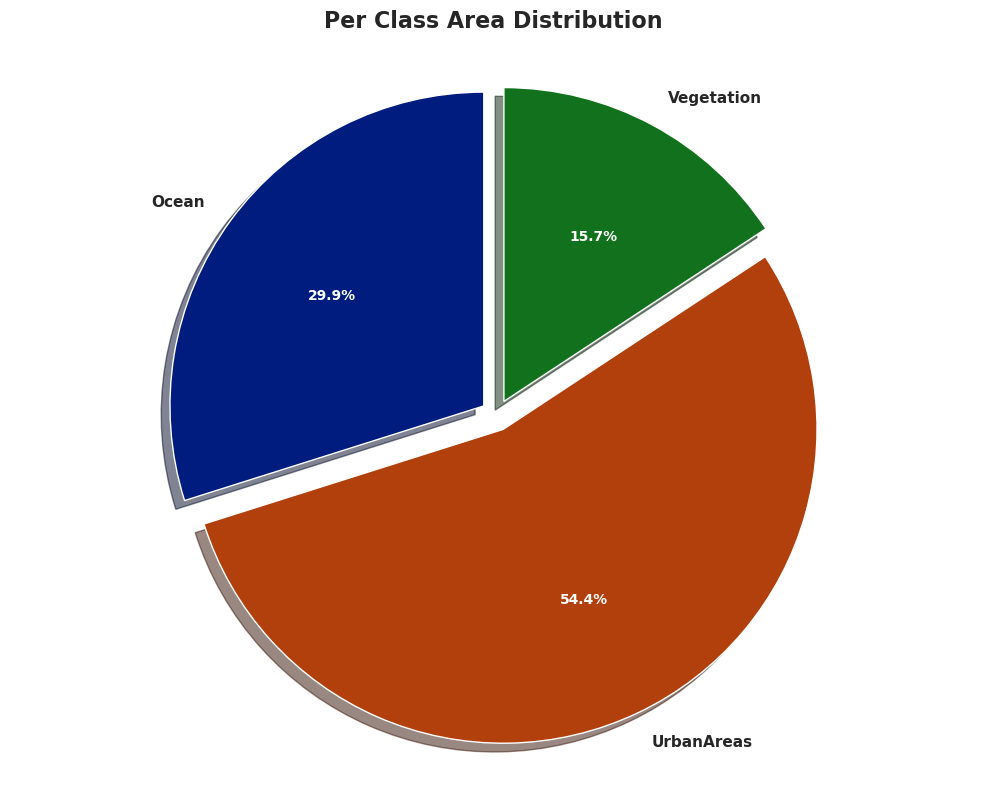

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set seaborn style for consistent aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11})

# Extract data
classes = list(normal_data[3].keys())
areas = list(normal_data[3].values())

# Create figure with better size
plt.figure(figsize=(10, 8))

# Use seaborn color palette
colors = sns.color_palette("dark", len(classes))
# Alternative palettes: "viridis", "Set2", "plasma", "deep", "pastel"

# Create pie chart with seaborn colors
wedges, texts, autotexts = plt.pie(areas, 
                                  labels=classes,
                                  colors=colors,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  explode=[0.05] * len(classes),  # Slight separation
                                  shadow=True,
                                  textprops={'fontweight': 'bold'})

# Customize the text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Improve label text
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')

# Add title
plt.title('Per Class Area Distribution', 
          fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Add a legend with area values
# legend_labels = [f'{cls}: {area:.1f} %' for cls, area in zip(classes, areas)]
# plt.legend(wedges, legend_labels,
#           title="Classes",
#           loc="center left",
#           bbox_to_anchor=(1, 0, 0.5, 1),
#           fontsize=10)

# Adjust layout to prevent legend cutoff
plt.tight_layout()

# Show the plot
# plt.show()

# Optional: Save the plot
plt.savefig('three_class_area_pie_chart.png', dpi=300, bbox_inches='tight')